In [1]:
import pandas as pd


In [4]:
df = pd.read_csv('employees_data_cleaned.csv')
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,74430,HR,region_4,Bachelors,f,other,1,31,3,5,0,0,51
1,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1,4,0,0,47
2,38562,Procurement,region_2,Bachelors,f,other,3,31,2,9,0,0,65
3,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4,7,0,0,61
4,46232,Procurement,region_7,Bachelors,m,sourcing,1,36,3,2,0,0,68


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16052 entries, 0 to 16051
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   employee_id            16052 non-null  int64 
 1   department             16052 non-null  object
 2   region                 16052 non-null  object
 3   education              15422 non-null  object
 4   gender                 16052 non-null  object
 5   recruitment_channel    16052 non-null  object
 6   no_of_trainings        16052 non-null  int64 
 7   age                    16052 non-null  int64 
 8   previous_year_rating   16052 non-null  int64 
 9   length_of_service      16052 non-null  int64 
 10  KPIs_met_more_than_80  16052 non-null  int64 
 11  awards_won             16052 non-null  int64 
 12  avg_training_score     16052 non-null  int64 
dtypes: int64(8), object(5)
memory usage: 1.6+ MB


In [6]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,16052.000000,16052.000000,16052.000000,16052.000000,16052.000000,16052.000000,16052.000000,16052.000000
mean,39098.462061,1.244269,35.486793,3.345751,6.209195,0.358398,0.023362,63.178732
std,22698.008726,0.584476,7.595459,1.265194,4.097874,0.479545,0.151054,13.352951
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19338.750000,1.000000,30.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39068.000000,1.000000,34.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58893.500000,1.000000,39.000000,4.000000,8.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [7]:
# Bucket age into bands
df['age_band'] = pd.cut(df['age'],bins=[20,30,40,50,60],labels=['20s','30s','40s','50s'])
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,age_band
0,74430,HR,region_4,Bachelors,f,other,1,31,3,5,0,0,51,30s
1,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1,4,0,0,47,30s
2,38562,Procurement,region_2,Bachelors,f,other,3,31,2,9,0,0,65,30s
3,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4,7,0,0,61,20s
4,46232,Procurement,region_7,Bachelors,m,sourcing,1,36,3,2,0,0,68,30s


In [8]:
#Bucket tenure into bands
df['tenure_band'] = pd.cut(df['length_of_service'],bins=[0,2,5,10,30], labels=['0-2yrs','3-5yrs','6-10yrs','10+yrs'])
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,age_band,tenure_band
0,74430,HR,region_4,Bachelors,f,other,1,31,3,5,0,0,51,30s,3-5yrs
1,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1,4,0,0,47,30s,3-5yrs
2,38562,Procurement,region_2,Bachelors,f,other,3,31,2,9,0,0,65,30s,6-10yrs
3,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4,7,0,0,61,20s,6-10yrs
4,46232,Procurement,region_7,Bachelors,m,sourcing,1,36,3,2,0,0,68,30s,0-2yrs


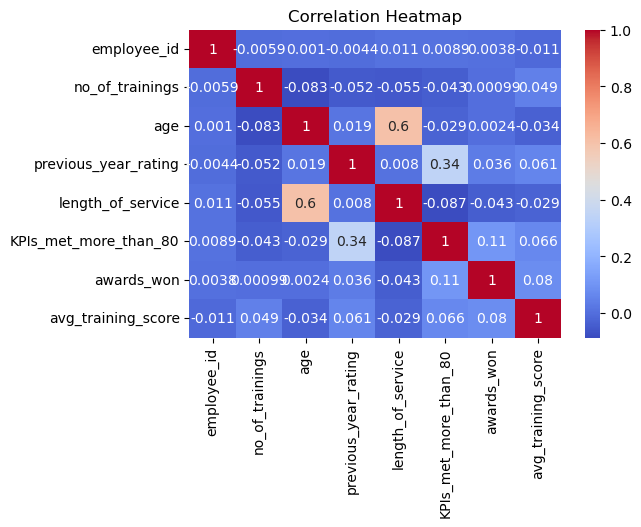

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

## Correlation heatmap
plt.figure(figsize=(6,4))
numeric_cols = df.select_dtypes(include='number')
sns.heatmap(numeric_cols.corr(), annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

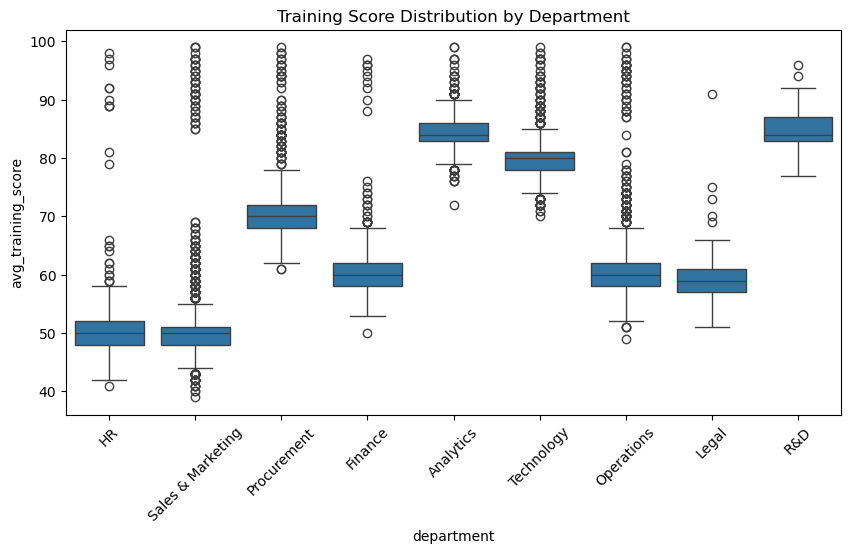

In [10]:
# Boxplot: training score by department
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='department', y='avg_training_score')
plt.xticks(rotation=45)
plt.title('Training Score Distribution by Department')
plt.show()

In [11]:
from scipy import stats

# Ho : There is no difference between trainig scores of masters and bachelore candidates
# H1: There is significant difference between training scores of masters and bachelores candidates

bachelors = df[df['education']=='Bachelors']['avg_training_score'].dropna()
masters = df[df['education']=="Masters & above"]['avg_training_score'].dropna()

t_stat, p_value = stats.ttest_ind(bachelors, masters)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print('We Reject the Null Hypothesis, There is significant difference between of masters and bachelores candidates')
else:
    print('We take the null Hypothesis, There is no significant difference between of masters and bachelores candidates')

T-statistic: -4.43, P-value: 0.0000
We Reject the Null Hypothesis, There is significant difference between of masters and bachelores candidates


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Select features and target
features = ['age', 'no_of_trainings', 'length_of_service', 'avg_training_score']
X = df[features].fillna(0)
y = df['KPIs_met_more_than_80']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f'Y prediction : {confusion_matrix(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

# Feature importance (coefficients)
for feature, coef in zip(features, model.coef_[0]):
    print(f"{feature}: {coef:.3f}")

Y prediction : [[2084    6]
 [1115    6]]
              precision    recall  f1-score   support

           0       0.65      1.00      0.79      2090
           1       0.50      0.01      0.01      1121

    accuracy                           0.65      3211
   macro avg       0.58      0.50      0.40      3211
weighted avg       0.60      0.65      0.52      3211

age: 0.010
no_of_trainings: -0.186
length_of_service: -0.060
avg_training_score: 0.011


In [13]:
#test association/dependence (for department) and correlation/effect (for training score)

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df.department, df.KPIs_met_more_than_80)
chi2, p, dof, expected = chi2_contingency(contingency)

print(f'chi2 : {chi2}, \n p: {p},\n dof: {dof}, \n expected: {expected}')

chi2 : 268.79630215860885, 
 p: 1.7716705767895505e-53,
 dof: 8, 
 expected: [[ 978.44349614  546.55650386]
 [ 467.08646898  260.91353102]
 [ 479.27691253  267.72308747]
 [ 184.78146025  103.21853975]
 [2146.80127087 1199.19872913]
 [1349.28962123  753.71037877]
 [ 195.68869923  109.31130077]
 [3204.80345128 1790.19654872]
 [1292.82861949  722.17138051]]


In [14]:
from scipy.stats import pointbiserialr, mannwhitneyu

## Correlation
corr, p_corr = pointbiserialr(df['KPIs_met_more_than_80'], df['avg_training_score'])
print(f"Correlation = {corr:.3f}, p-value = {p_corr:.4f}")

## Group comparison
met = df[df['KPIs_met_more_than_80'] == 1]['avg_training_score']
not_met = df[df['KPIs_met_more_than_80'] == 0]['avg_training_score']

stat, p_mw = mannwhitneyu(met, not_met)
print(f"Mann-Whitney p-value = {p_mw:.4f}")

Correlation = 0.066, p-value = 0.0000
Mann-Whitney p-value = 0.0000


In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Since KPI Score is binary, We use logistic regression

model = smf.logit('KPIs_met_more_than_80 ~ C(department) + avg_training_score', data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.643760
         Iterations 5
                             Logit Regression Results                            
Dep. Variable:     KPIs_met_more_than_80   No. Observations:                16052
Model:                             Logit   Df Residuals:                    16042
Method:                              MLE   Df Model:                            9
Date:                   Fri, 03 Jul 2026   Pseudo R-squ.:                 0.01338
Time:                           12:27:21   Log-Likelihood:                -10334.
converged:                          True   LL-Null:                       -10474.
Covariance Type:               nonrobust   LLR p-value:                 3.926e-55
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                           